In [21]:
# -*- coding: utf-8 -*-
"""
Linear evaluation (Logistic Regression) for contrastive encoder.
使用训练好的 model_q（contrastive_main.pt）提取 embedding，
然后在 Adult 的原始 train/test 上评估分类性能。
"""

import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

from contrastive_model import ContrastiveModel_Main
from contrastive_train import load_info, build_global_category_encoders
from contrastive_train import get_category_cardinalities_from_full
from contrastive_train import codes_to_onehot

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score,f1_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATANAME = "adult"
INFO_PATH = f"data/{DATANAME}/info.json"
TRAIN_CSV = f"data/{DATANAME}/train.csv"
TEST_CSV  = f"data/{DATANAME}/test.csv"


#  工具：把原始 CSV 转成 x_num, x_cat
def encode_raw_csv(csv_path, info, encoders):
    df = pd.read_csv(csv_path)

    num_idx = info["num_col_idx"]
    cat_idx = info["cat_col_idx"]
    label_idx = info["target_col_idx"][0]

    x_num = torch.tensor(df.iloc[:, num_idx].values, dtype=torch.float32)

    # 用“全局映射”编码类别列（与 contrastive_train 完全一致）
    x_cat_list = []
    for i, col_idx in enumerate(cat_idx):
        mapping = encoders[i]
        col = df.iloc[:, col_idx].map(mapping).fillna(0).astype(int)
        x_cat_list.append(torch.tensor(col.values, dtype=torch.int64).unsqueeze(1))
    x_cat = torch.cat(x_cat_list, dim=1)

    # 标签转换成 0/1
    y_raw = df.iloc[:, label_idx]

    # Adult 的标签是字符串类型，需要手动转换
    # 自动判断
    if y_raw.dtype == object:
        y = torch.tensor(
            (y_raw.astype(str).str.contains(">50K")).astype(int).values,
            dtype=torch.int64
        )
    else:
        y = torch.tensor(y_raw.values, dtype=torch.int64)

    return x_num, x_cat, y



# 1. 加载 info 和全局类别映射
info = load_info(INFO_PATH)

print("cat_col_idx =", info["cat_col_idx"])

Ks = get_category_cardinalities_from_full(TRAIN_CSV, info)
encoders = build_global_category_encoders(TRAIN_CSV, info)
d_num = len(info["num_col_idx"])

print("[INFO] 类别全集基数 =", Ks)

# 2. 创建并加载训练好的 encoder
model_q = ContrastiveModel_Main(
    num_continuous=d_num,
    categories=Ks,
    d_token=64,
    transformer_dim=128,
    n_heads=4,
    num_layers=2,
    proj_out_dim=256,
    pred_hidden_dim=1024,
).to(DEVICE)

state = torch.load("ckpts/contrastive_main.pt", map_location=DEVICE)
model_q.load_state_dict(state)
model_q.eval()

# 3. 处理原始 train.csv / test.csv
x_num_train, x_cat_train, y_train = encode_raw_csv(TRAIN_CSV, info, encoders)
x_num_test, x_cat_test, y_test = encode_raw_csv(TEST_CSV, info, encoders)

x_num_train = x_num_train.to(DEVICE)
x_cat_train = x_cat_train.to(DEVICE)
x_num_test  = x_num_test.to(DEVICE)
x_cat_test  = x_cat_test.to(DEVICE)

x_cat_train_oh = codes_to_onehot(x_cat_train, Ks).to(DEVICE)
x_cat_test_oh  = codes_to_onehot(x_cat_test, Ks).to(DEVICE)

with torch.no_grad():
    p_train, z_train = model_q(x_num_train, x_cat_train_oh)
    p_test,  z_test  = model_q(x_num_test,  x_cat_test_oh)

Z_train = z_train.cpu().numpy()
Z_test  = z_test.cpu().numpy()
Y_train = y_train.numpy()
Y_test  = y_test.numpy()

print("[INFO] Embedding 维度:", Z_train.shape)

# 5. 线性分类器：Logistic Regression
clf = LogisticRegression(max_iter=2000)
clf.fit(Z_train, Y_train)

y_pred = clf.predict(Z_test)
y_prob = clf.predict_proba(Z_test)[:, 1]

acc = accuracy_score(Y_test, y_pred)
auc = roc_auc_score(Y_test, y_prob)
f1 = f1_score(Y_test, y_pred)

print("\n========== Linear Probe 结果 ==========")
print("Accuracy = %.4f" % acc)
print("AUC      = %.4f" % auc)
print("F1 Score = %.4f" % f1)
print("=======================================")


cat_col_idx = [1, 3, 5, 6, 7, 8, 9, 13]
[INFO] 类别全集基数 = [9, 16, 7, 15, 6, 5, 2, 42]
[INFO] Embedding 维度: (32561, 256)

========== Linear Probe 结果 ==========
Accuracy = 0.8360
AUC      = 0.8854
F1 Score = 0.6415


ARI = 0.20267539191945455
NMI = 0.1679307901437555


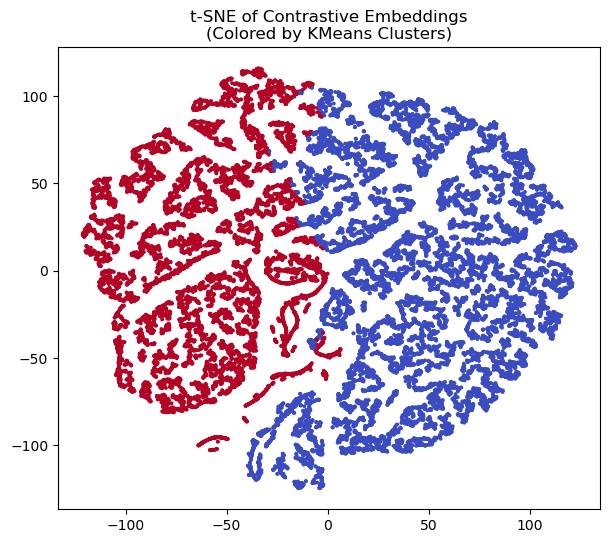

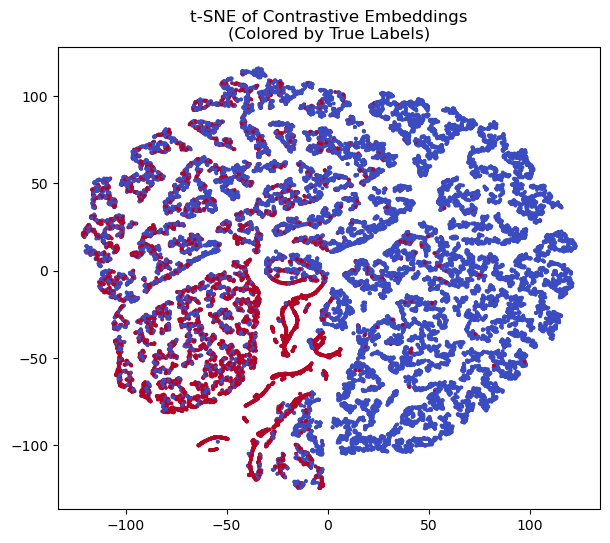

In [22]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ======================
# 1) KMeans 聚类
# ======================
n_clusters = 2   # Adult 二分类：<=50K, >50K

kmeans = KMeans(n_clusters=n_clusters, random_state=0)
cluster_labels = kmeans.fit_predict(Z_train)

# ======================
# 2) 聚类指标
# ======================
ari = adjusted_rand_score(Y_train, cluster_labels)
nmi = normalized_mutual_info_score(Y_train, cluster_labels)

print("ARI =", ari)
print("NMI =", nmi)

# ======================
# 3) t-SNE 可视化
# ======================
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
Z_2d = tsne.fit_transform(Z_train)

plt.figure(figsize=(7, 6))
plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=cluster_labels, cmap="coolwarm", s=3)
plt.title("t-SNE of Contrastive Embeddings\n(Colored by KMeans Clusters)")
plt.show()

# ======================
# 4) t-SNE 可视化（真实标签）
# ======================
plt.figure(figsize=(7, 6))
plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y_train, cmap="coolwarm", s=3)
plt.title("t-SNE of Contrastive Embeddings\n(Colored by True Labels)")
plt.show()
